In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries imported ✅")

Libraries imported ✅


In [29]:
df = pd.read_csv("C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/cleaned_retail.csv")

# Fix date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape:", df.shape)
print("Date range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
df.head()

Shape: (776577, 15)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday,4


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776577 entries, 0 to 776576
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      776577 non-null  int64         
 1   StockCode    776577 non-null  object        
 2   Description  776577 non-null  object        
 3   Quantity     776577 non-null  int64         
 4   InvoiceDate  776577 non-null  datetime64[ns]
 5   Price        776577 non-null  float64       
 6   Customer ID  776577 non-null  int64         
 7   Country      776577 non-null  object        
 8   Revenue      776577 non-null  float64       
 9   Year         776577 non-null  int64         
 10  Month        776577 non-null  int64         
 11  Day          776577 non-null  int64         
 12  Hour         776577 non-null  int64         
 13  DayOfWeek    776577 non-null  object        
 14  Quarter      776577 non-null  int64         
dtypes: datetime64[ns](1), float64(2), 

In [31]:
print("=" * 50)
print("📊 BUSINESS OVERVIEW")
print("=" * 50)
print(f"Total Revenue:       £{df['Revenue'].sum():,.2f}")
print(f"Total Orders:        {df['Invoice'].nunique():,}")
print(f"Total Customers:     {df['Customer ID'].nunique():,}")
print(f"Total Products:      {df['StockCode'].nunique():,}")
print(f"Total Countries:     {df['Country'].nunique():,}")
print(f"Avg Order Value:     £{df.groupby('Invoice')['Revenue'].sum().mean():,.2f}")
print(f"Avg Revenue/Customer:£{df.groupby('Customer ID')['Revenue'].sum().mean():,.2f}")
print("=" * 50)

📊 BUSINESS OVERVIEW
Total Revenue:       £17,068,567.97
Total Orders:        36,594
Total Customers:     5,852
Total Products:      4,619
Total Countries:     41
Avg Order Value:     £466.43
Avg Revenue/Customer:£2,916.71


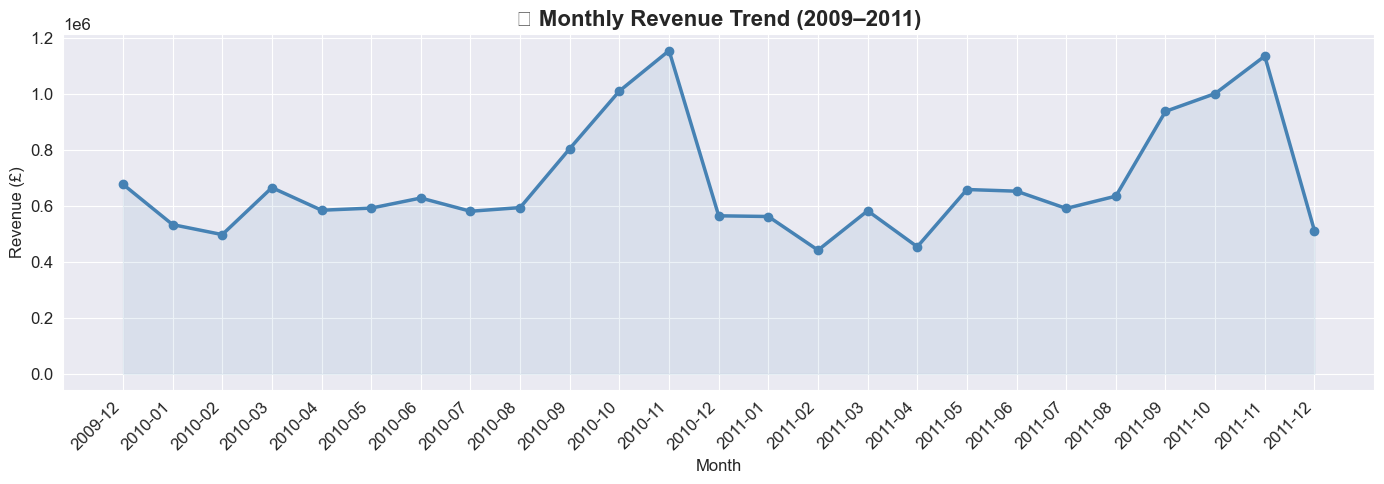

📌 Best Month: 2010-11 — £1,155,978.39


In [33]:
# Business Question: How has revenue grown month by month?

monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['InvoiceDate'], monthly['Revenue'], 
        marker='o', color='steelblue', linewidth=2.5, markersize=6)
ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly)), monthly['InvoiceDate'], rotation=45, ha='right')
plt.title('📈 Monthly Revenue Trend (2009–2011)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/01_monthly_revenue.png', dpi=150)
plt.show()

best_month = monthly.loc[monthly['Revenue'].idxmax()]
print(f"📌 Best Month: {best_month['InvoiceDate']} — £{best_month['Revenue']:,.2f}")

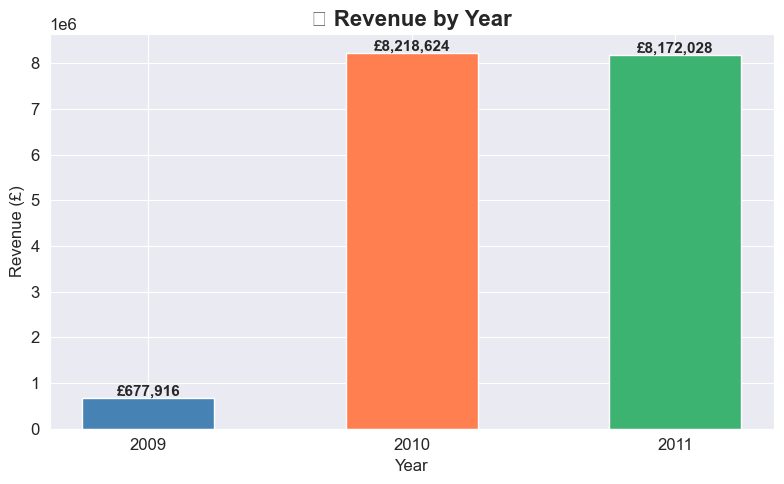

In [34]:
# Business Question: How did revenue compare year on year?

yearly = df.groupby('Year')['Revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly['Year'].astype(str), yearly['Revenue'], 
              color=['steelblue','coral','mediumseagreen'], width=0.5)

# Add value labels on bars
for bar, val in zip(bars, yearly['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'£{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.title('📊 Revenue by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/02_yearly_revenue.png', dpi=150)
plt.show()

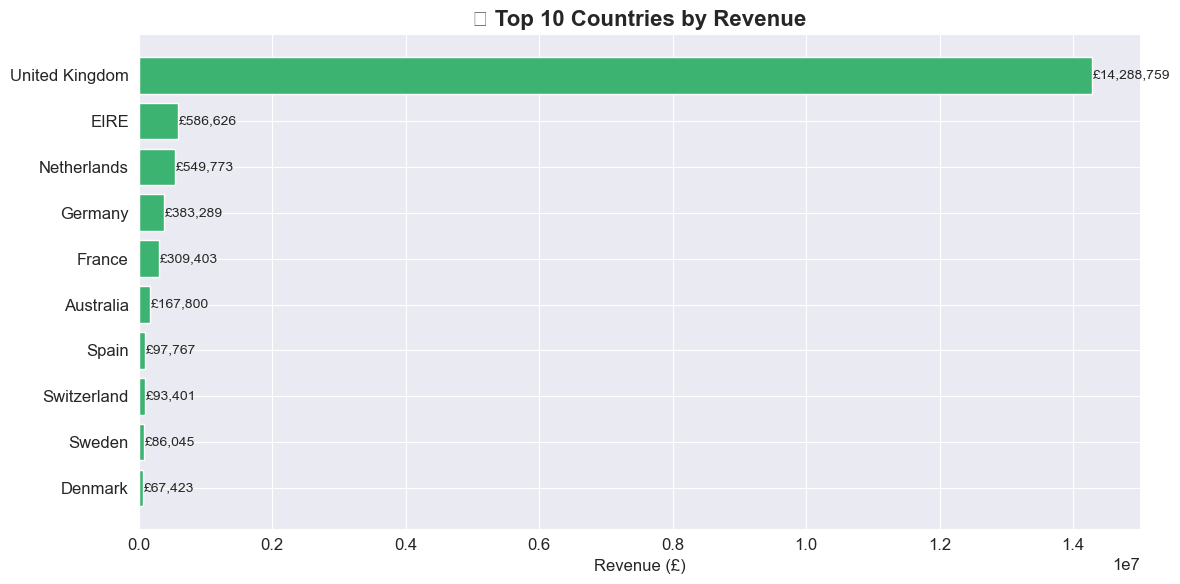

In [35]:
# Business Question: Which countries generate most revenue?

top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_countries['Country'], top_countries['Revenue'], color='mediumseagreen')

for bar, val in zip(bars, top_countries['Revenue']):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10)

plt.title('🌍 Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/03_top_countries.png', dpi=150)
plt.show()

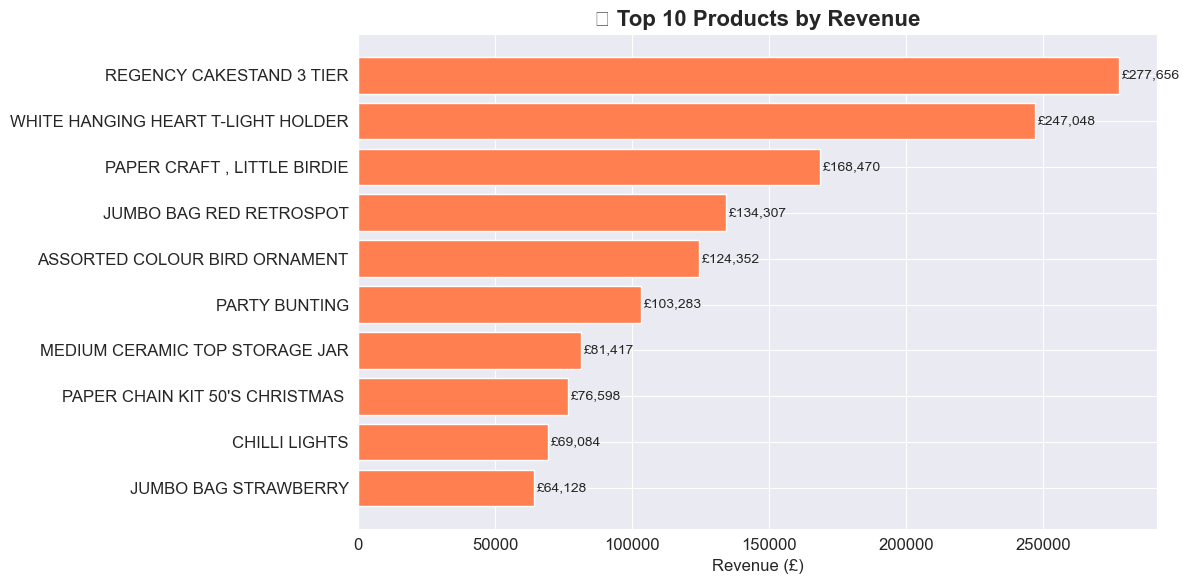

In [36]:
# Business Question: Which products make the most money?

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products['Description'], top_products['Revenue'], color='coral')

for bar, val in zip(bars, top_products['Revenue']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10)

plt.title('🏆 Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/04_top_products.png', dpi=150)
plt.show()

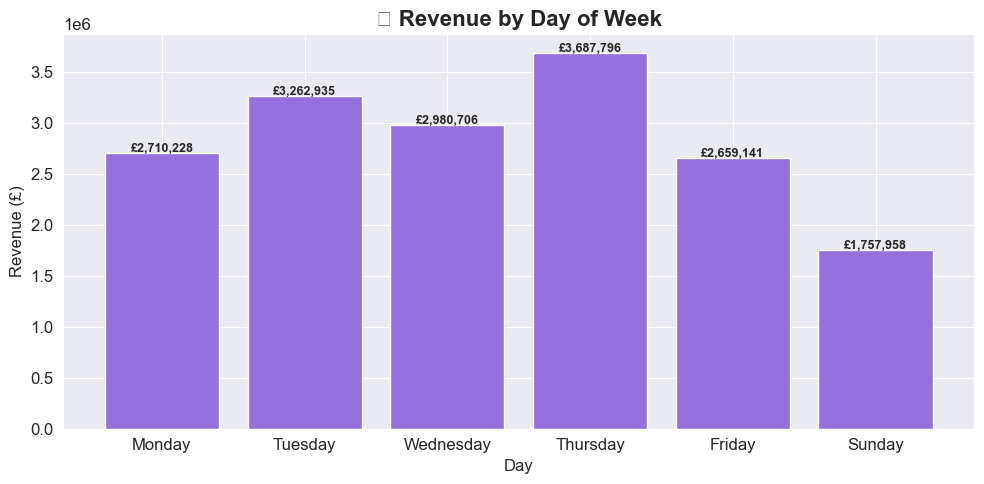

📌 Best Day: Thursday


In [37]:
# Business Question: Which day of week has highest sales?

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
day_revenue = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_revenue['DayOfWeek'], day_revenue['Revenue'], color='mediumpurple')

for bar, val in zip(bars, day_revenue['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.title('📅 Revenue by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/05_day_revenue.png', dpi=150)
plt.show()

print(f"📌 Best Day: {day_revenue.loc[day_revenue['Revenue'].idxmax(), 'DayOfWeek']}")

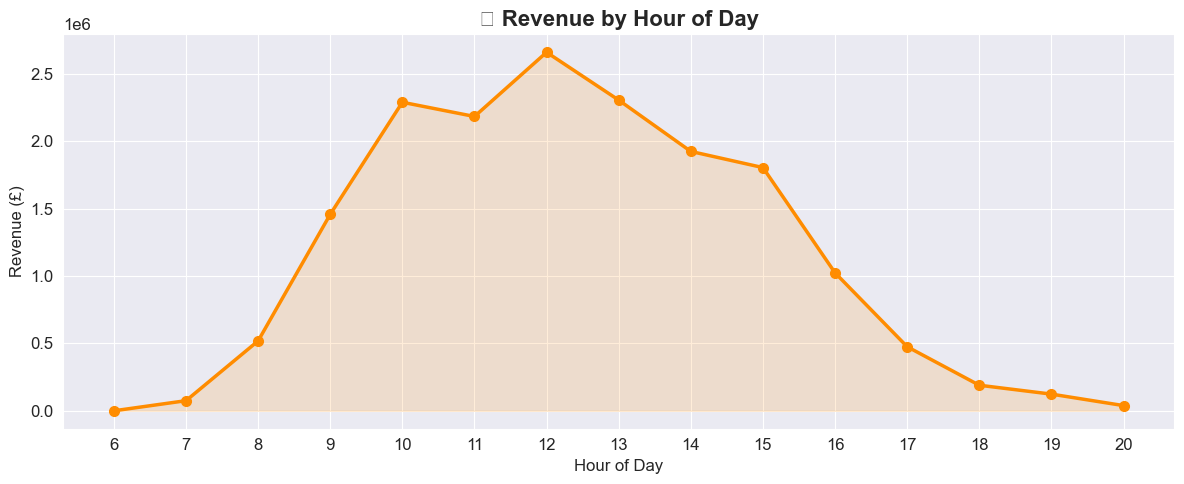

📌 Peak Hour: 12:00


In [38]:
# Business Question: What time of day do most sales happen?

hour_revenue = df.groupby('Hour')['Revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hour_revenue['Hour'], hour_revenue['Revenue'],
        marker='o', color='darkorange', linewidth=2.5, markersize=7)
ax.fill_between(hour_revenue['Hour'], hour_revenue['Revenue'], alpha=0.15, color='darkorange')

plt.title('⏰ Revenue by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (£)')
plt.xticks(hour_revenue['Hour'])
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/06_hour_revenue.png', dpi=150)
plt.show()

print(f"📌 Peak Hour: {hour_revenue.loc[hour_revenue['Revenue'].idxmax(), 'Hour']}:00")

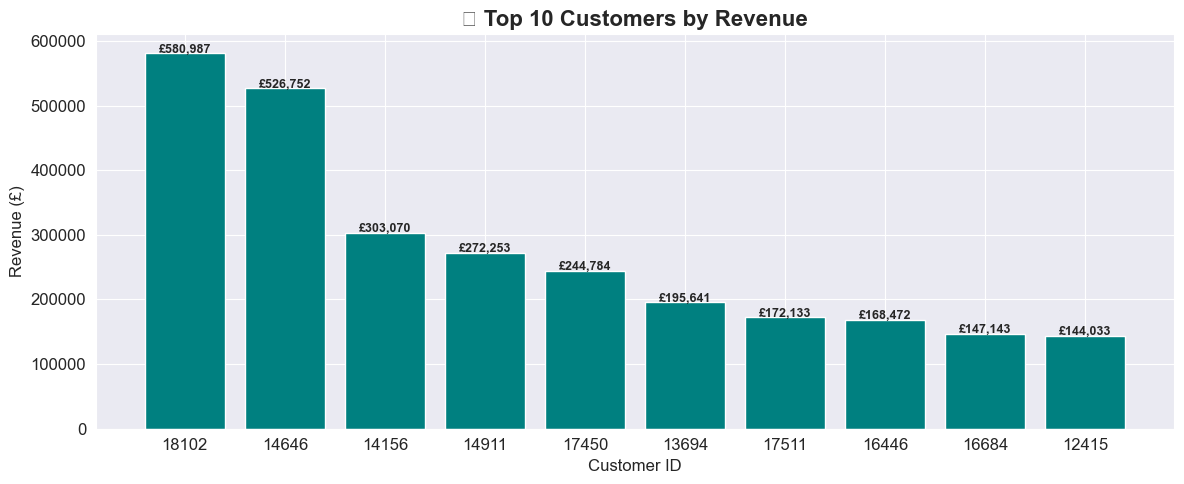

In [39]:
# Business Question: Who are our most valuable customers?

top_customers = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_customers['Customer ID'].astype(str), top_customers['Revenue'], color='teal')

for bar, val in zip(bars, top_customers['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.title('👑 Top 10 Customers by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/07_top_customers.png', dpi=150)
plt.show()

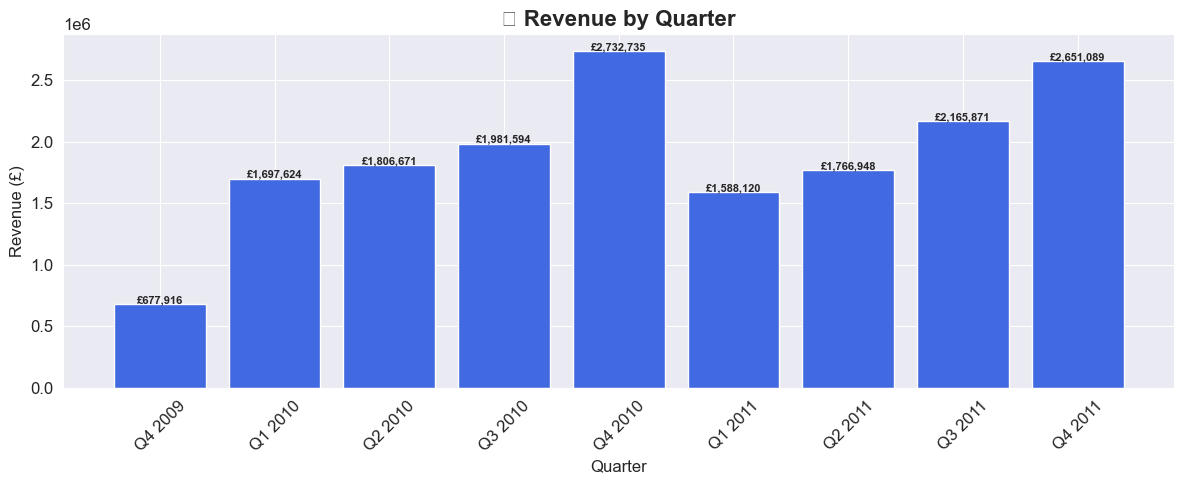

In [40]:
# Business Question: Which quarter performs best?

quarter_revenue = df.groupby(['Year','Quarter'])['Revenue'].sum().reset_index()
quarter_revenue['Period'] = 'Q' + quarter_revenue['Quarter'].astype(str) + ' ' + quarter_revenue['Year'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(quarter_revenue['Period'], quarter_revenue['Revenue'], color='royalblue')

for bar, val in zip(bars, quarter_revenue['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'£{val:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.title('📆 Revenue by Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/08_quarter_revenue.png', dpi=150)
plt.show()

In [41]:
print("=" * 55)
print("📊 EDA COMPLETE — KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"💰 Total Revenue:         £{df['Revenue'].sum():,.2f}")
print(f"🛒 Total Orders:          {df['Invoice'].nunique():,}")
print(f"👥 Total Customers:       {df['Customer ID'].nunique():,}")
print(f"📦 Total Products:        {df['StockCode'].nunique():,}")
print(f"🌍 Total Countries:       {df['Country'].nunique():,}")
print(f"📈 Best Month:            {monthly.loc[monthly['Revenue'].idxmax(), 'InvoiceDate']}")
print(f"📅 Best Day:              {day_revenue.loc[day_revenue['Revenue'].idxmax(), 'DayOfWeek']}")
print(f"⏰ Peak Hour:             {hour_revenue.loc[hour_revenue['Revenue'].idxmax(), 'Hour']}:00")
print(f"🌍 Top Country:           {top_countries.loc[0, 'Country']}")
print(f"🏆 Top Product:           {top_products.loc[0, 'Description']}")
print(f"👑 Top Customer Revenue:  £{top_customers.loc[0, 'Revenue']:,.2f}")
print("=" * 55)

📊 EDA COMPLETE — KEY BUSINESS INSIGHTS
💰 Total Revenue:         £17,068,567.97
🛒 Total Orders:          36,594
👥 Total Customers:       5,852
📦 Total Products:        4,619
🌍 Total Countries:       41
📈 Best Month:            2010-11
📅 Best Day:              Thursday
⏰ Peak Hour:             12:00
🌍 Top Country:           United Kingdom
🏆 Top Product:           REGENCY CAKESTAND 3 TIER
👑 Top Customer Revenue:  £580,987.04
